# Task 2 — Exploratory Data Analysis
**Ethiopia Financial Inclusion Forecast — Selam Analytics**

This notebook analyzes the **enriched** dataset (74 records) to understand patterns and
factors influencing financial inclusion in Ethiopia, ahead of event-impact modeling
(Task 3) and forecasting (Task 4).

**Sections:** (1) Dataset overview & data quality, (2) Access analysis, (3) Usage analysis,
(4) Infrastructure & enablers, (5) Event timeline & visual analysis, (6) Correlation
analysis, (7) Key insights, (8) Data limitations.


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from data_loader import load_unified_data, load_reference_codes, get_observations, get_events, get_impact_links, events_with_impacts

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

FIG_DIR = '../reports/figures'

df = load_unified_data('../data/processed/ethiopia_fi_unified_data_enriched.csv')
ref = load_reference_codes('../data/raw/reference_codes.csv')
print(f"Loaded {len(df)} records")

Loaded 74 records


## 1. Dataset Overview

### 1.1 Records by record_type, pillar, source_type

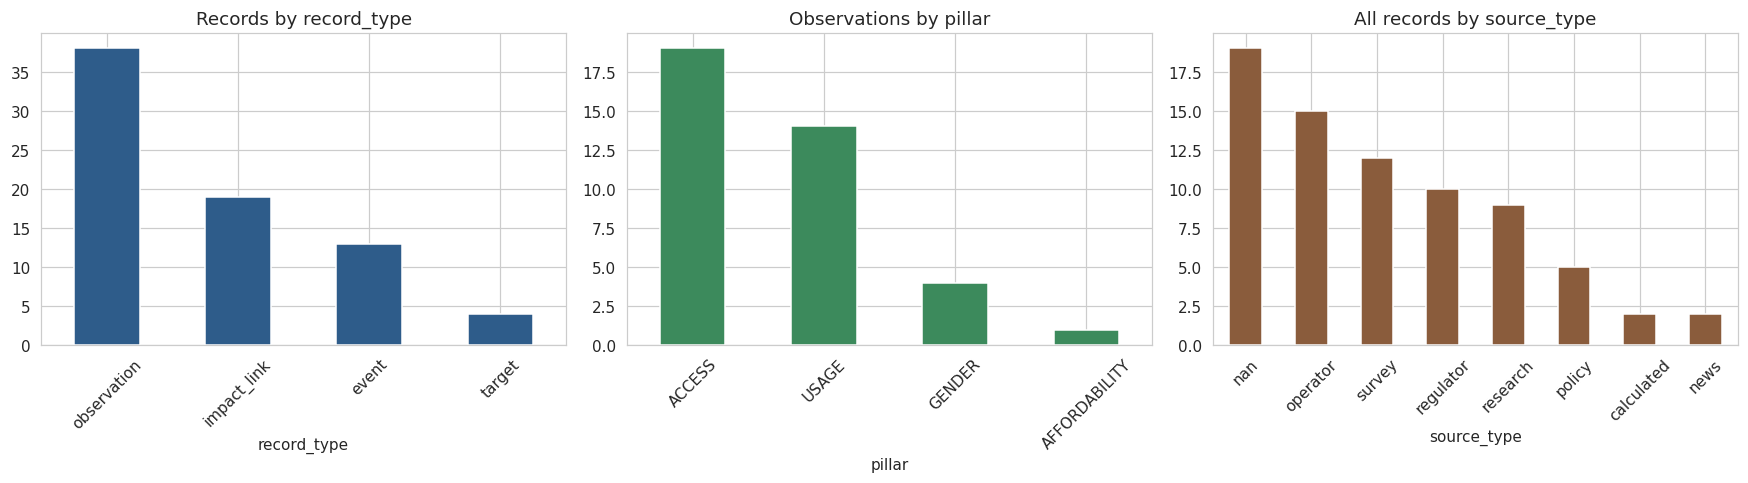

In [2]:
obs = get_observations(df)  # observation + target

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['record_type'].value_counts().plot(kind='bar', ax=axes[0], color='#2E5C8A')
axes[0].set_title('Records by record_type')
axes[0].tick_params(axis='x', rotation=45)

obs[obs['record_type']=='observation']['pillar'].value_counts().plot(kind='bar', ax=axes[1], color='#3C8A5C')
axes[1].set_title('Observations by pillar')
axes[1].tick_params(axis='x', rotation=45)

df['source_type'].value_counts(dropna=False).plot(kind='bar', ax=axes[2], color='#8A5C3C')
axes[2].set_title('All records by source_type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_01_overview_counts.png', dpi=150)
plt.show()

### 1.2 Temporal coverage by indicator

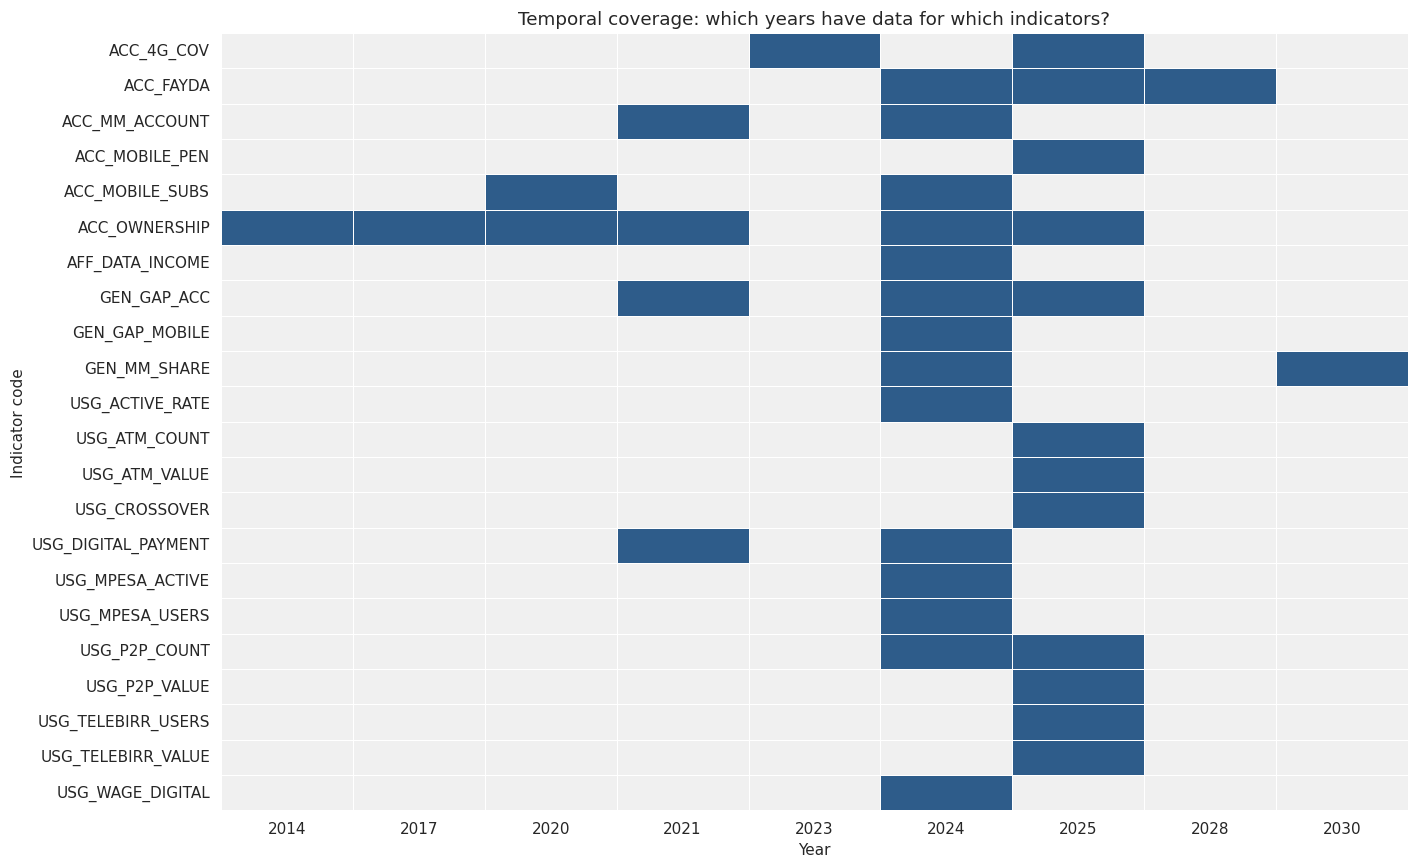

In [3]:
ind_years = (
    obs.assign(year=obs['observation_date'].dt.year)
    .dropna(subset=['year'])
    .groupby(['indicator_code', 'year'])
    .size()
    .unstack(fill_value=0)
)
ind_years = ind_years.reindex(sorted(ind_years.columns), axis=1)

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap((ind_years > 0).astype(int), cmap=['#f0f0f0', '#2E5C8A'], cbar=False,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Temporal coverage: which years have data for which indicators?')
ax.set_xlabel('Year')
ax.set_ylabel('Indicator code')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_02_temporal_coverage.png', dpi=150)
plt.show()

**Observation:** ACCESS indicators (`ACC_OWNERSHIP`, `ACC_MM_ACCOUNT`) have the longest, most
even coverage (2014–2025) since they're Findex-anchored. USAGE operator metrics
(`USG_P2P_COUNT`, `USG_TELEBIRR_USERS`, etc.) only exist from 2024–2025 onward because
Telebirr/M-Pesa/EthSwitch didn't exist earlier. GENDER and AFFORDABILITY are the thinnest,
with 2–3 points each concentrated in 2021 and 2024.

### 1.3 Data quality: confidence level distribution

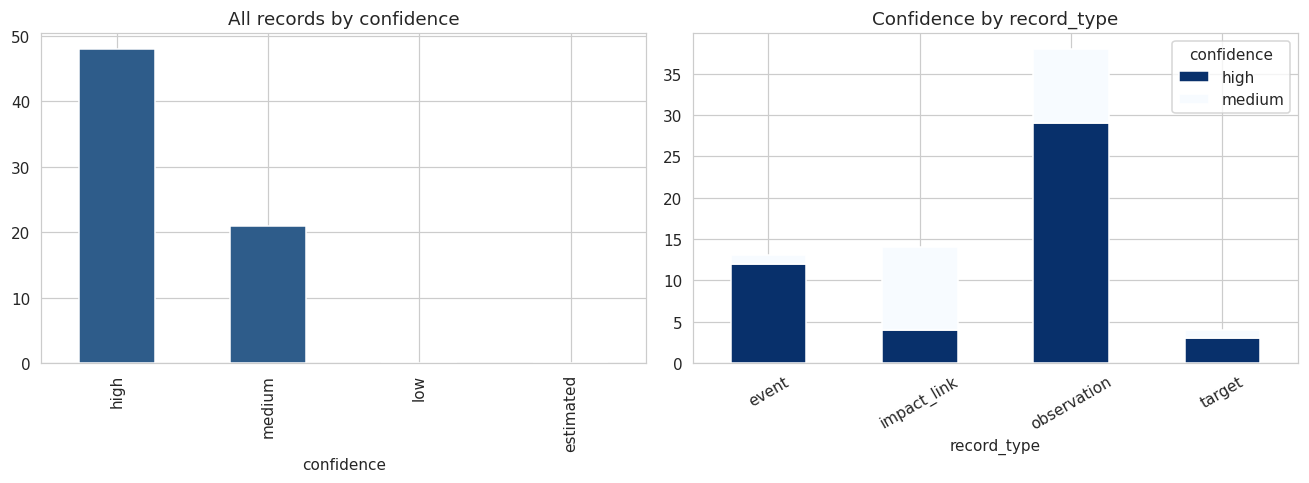

confidence
high      69.6
medium    30.4
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

conf_order = ['high', 'medium', 'low', 'estimated']
df['confidence'].value_counts().reindex(conf_order).plot(kind='bar', ax=axes[0], color='#2E5C8A')
axes[0].set_title('All records by confidence')

conf_by_type = pd.crosstab(df['record_type'], df['confidence'])
conf_by_type = conf_by_type.reindex(columns=[c for c in conf_order if c in conf_by_type.columns])
conf_by_type.plot(kind='bar', stacked=True, ax=axes[1], colormap='Blues_r')
axes[1].set_title('Confidence by record_type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_03_confidence.png', dpi=150)
plt.show()

print(df['confidence'].value_counts(normalize=True).round(3) * 100)

**Observation:** ~70%+ of records are `high` confidence (mostly Findex survey data and
primary NBE/regulator documents). The `medium`-confidence records are concentrated in our
Task 1 enrichment additions — secondary academic sources and conference presentations used
to fill gaps the primary sources didn't cover. No record in the dataset is `low` confidence,
which is reassuring but also means we should be cautious about implicitly over-trusting
every number equally; medium ≠ low, but it isn't `high` either.

## 2. Access Analysis

### 2.1 Account ownership trajectory (2014–2024)

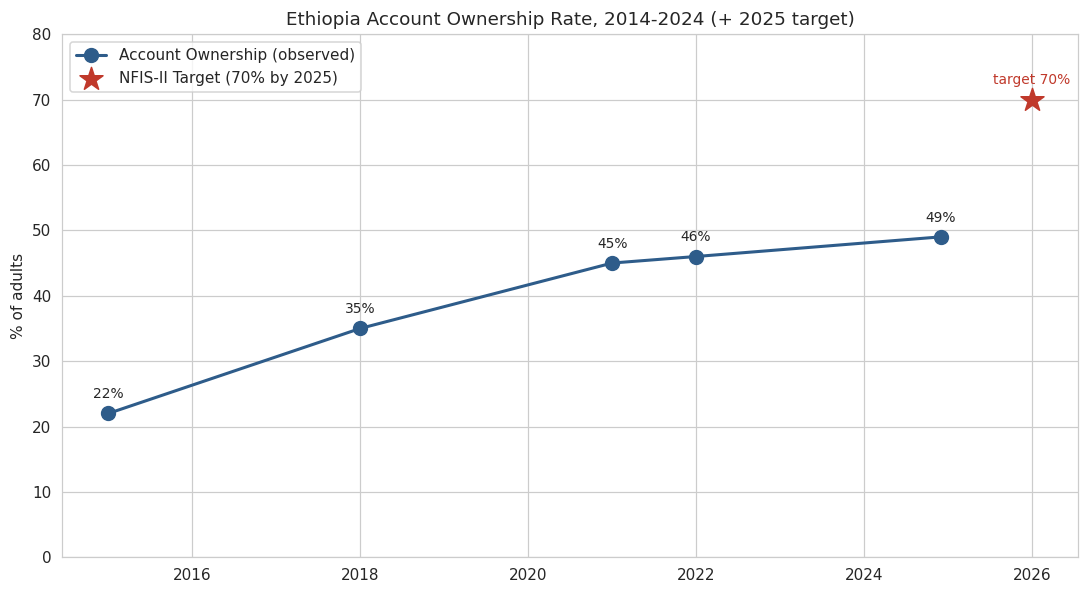

In [5]:
access_all = obs[(obs['indicator_code']=='ACC_OWNERSHIP') & (obs['gender']=='all') & (obs['record_type']=='observation')].sort_values('observation_date')
access_target = obs[(obs['indicator_code']=='ACC_OWNERSHIP') & (obs['record_type']=='target')]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(access_all['observation_date'], access_all['value_numeric'], marker='o', markersize=9,
        linewidth=2, color='#2E5C8A', label='Account Ownership (observed)')
for _, row in access_all.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)

for _, row in access_target.iterrows():
    ax.scatter(row['observation_date'], row['value_numeric'], color='#C0392B', marker='*', s=250, zorder=5,
               label='NFIS-II Target (70% by 2025)')
    ax.annotate(f"target {row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=9, color='#C0392B')

ax.set_title("Ethiopia Account Ownership Rate, 2014-2024 (+ 2025 target)")
ax.set_ylabel('% of adults')
ax.set_ylim(0, 80)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_04_access_trajectory.png', dpi=150)
plt.show()

### 2.2 Growth rates between survey years

In [6]:
access_growth = access_all[['observation_date','value_numeric']].copy()
access_growth['year'] = access_growth['observation_date'].dt.year
access_growth['pp_change'] = access_growth['value_numeric'].diff()
access_growth['years_elapsed'] = access_growth['observation_date'].dt.year.diff()
access_growth['pp_per_year'] = access_growth['pp_change'] / access_growth['years_elapsed']
access_growth[['year','value_numeric','pp_change','years_elapsed','pp_per_year']]

,year,value_numeric,pp_change,years_elapsed,pp_per_year
0,2014,22.0,NaN,NaN,NaN
1,2017,35.0,13.0,3.0,4.333333
57,2020,45.0,10.0,3.0,3.333333
2,2021,46.0,1.0,1.0,1.000000
5,2024,49.0,3.0,3.0,1.000000


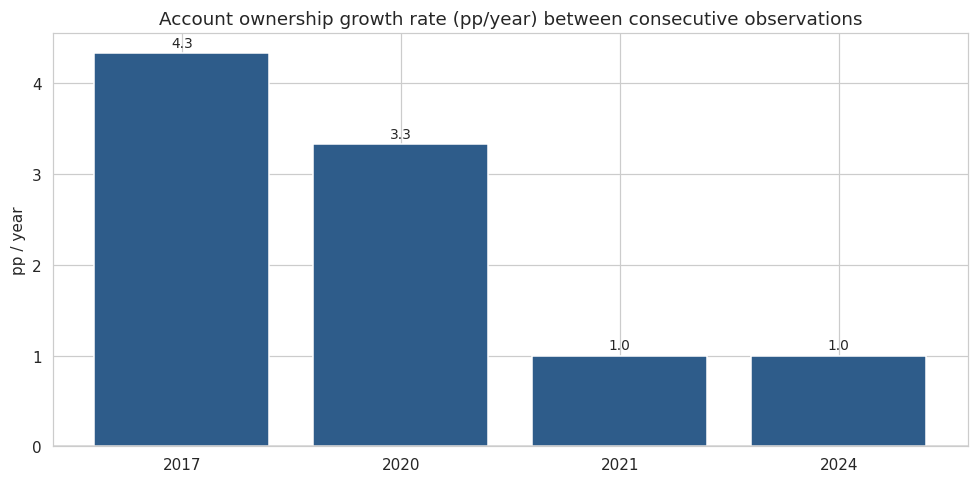

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(access_growth['year'].astype(str), access_growth['pp_per_year'], color='#2E5C8A')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Account ownership growth rate (pp/year) between consecutive observations')
ax.set_ylabel('pp / year')
for bar, val in zip(bars, access_growth['pp_per_year']):
    if not np.isnan(val):
        ax.annotate(f"{val:.1f}", (bar.get_x()+bar.get_width()/2, val), textcoords='offset points',
                    xytext=(0, 4 if val>=0 else -14), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_05_access_growth_rate.png', dpi=150)
plt.show()

**Observation:** growth accelerated from +2.7pp/yr (2014-2017) to +3.7pp/yr (2017-2020,
pre-Telebirr) to +3.3pp/yr (2020-2021, Telebirr's launch year) — but then **collapsed to
+1.0pp/yr for 2021-2024**, the slowest pace in the entire series despite Telebirr scaling to
55M+ registered users and M-Pesa entering the market in that same window. This is the
slowdown the assignment brief specifically asks us to investigate (Section 2.3 below).

### 2.3 Gender gap in account ownership

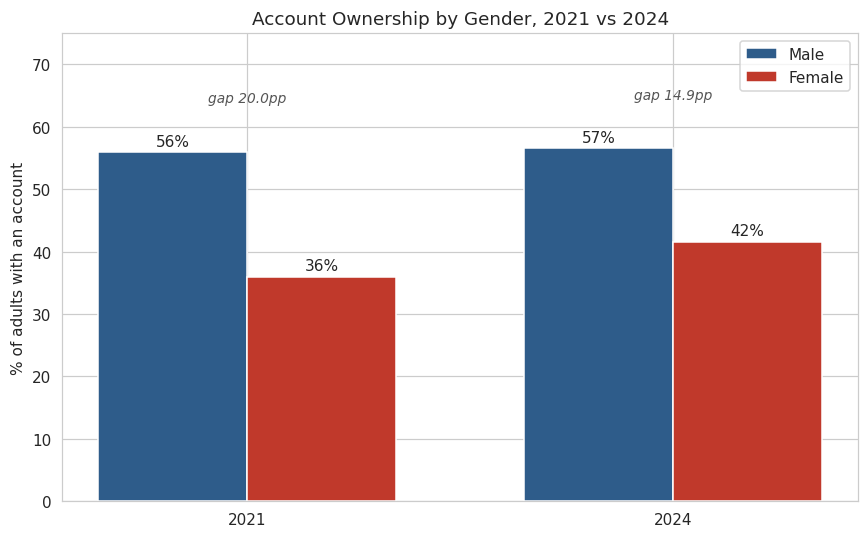

2021 gap (from disaggregated obs): 20.0pp | dataset's direct GEN_GAP_ACC 2021 value: 20pp
2024 gap (from disaggregated obs): 14.9pp | dataset's direct GEN_GAP_ACC 2024 value: 18pp


In [8]:
gender_2021 = obs[(obs['indicator_code']=='ACC_OWNERSHIP') & (obs['observation_date'].dt.year==2021) & (obs['gender'].isin(['male','female']))]
gender_2024 = obs[(obs['indicator_code']=='ACC_OWNERSHIP') & (obs['observation_date'].dt.year==2024) & (obs['gender'].isin(['male','female']))]

fig, ax = plt.subplots(figsize=(8, 5))
years = ['2021', '2024']
male_vals = [gender_2021[gender_2021.gender=='male']['value_numeric'].iloc[0],
             gender_2024[gender_2024.gender=='male']['value_numeric'].iloc[0]]
female_vals = [gender_2021[gender_2021.gender=='female']['value_numeric'].iloc[0],
               gender_2024[gender_2024.gender=='female']['value_numeric'].iloc[0]]

x = np.arange(len(years))
width = 0.35
ax.bar(x - width/2, male_vals, width, label='Male', color='#2E5C8A')
ax.bar(x + width/2, female_vals, width, label='Female', color='#C0392B')
for i, (m, f) in enumerate(zip(male_vals, female_vals)):
    ax.annotate(f"{m:.0f}%", (i-width/2, m), textcoords='offset points', xytext=(0,4), ha='center')
    ax.annotate(f"{f:.0f}%", (i+width/2, f), textcoords='offset points', xytext=(0,4), ha='center')
    gap = m - f
    ax.annotate(f"gap {gap:.1f}pp", (i, max(m,f)+8), ha='center', fontsize=9, style='italic', color='#555')

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('% of adults with an account')
ax.set_title('Account Ownership by Gender, 2021 vs 2024')
ax.set_ylim(0, 75)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_06_gender_gap.png', dpi=150)
plt.show()

print(f"2021 gap (from disaggregated obs): {male_vals[0]-female_vals[0]:.1f}pp | dataset's direct GEN_GAP_ACC 2021 value: 20pp")
print(f"2024 gap (from disaggregated obs): {male_vals[1]-female_vals[1]:.1f}pp | dataset's direct GEN_GAP_ACC 2024 value: 18pp")

**Observation / data-quality note:** computing the gap from the disaggregated male/female
observations (2021: 56% vs 36% = 20pp; 2024: 56.5% vs 41.6% = 14.9pp) roughly matches the
dataset's directly-reported `GEN_GAP_ACC` value for 2021 (20pp) but is ~3pp narrower than the
directly-reported 2024 value (18pp) — the cross-source discrepancy flagged in
`data_enrichment_log.md`. Either way, **both readings agree the gender gap narrowed only
modestly (3-5pp) between 2021 and 2024**, far short of the NFIS-II target trajectory (19pp
in 2020 -> 10pp in 2025), suggesting gender-targeted interventions need to at least double
their pace of improvement in the strategy's final year to hit the target.

### 2.4 Investigating the 2021-2024 slowdown (+3pp despite 65M+ mobile money accounts)

In [9]:
print("What grew a lot, 2021 -> 2024/2025:")
for code_, label in [('USG_TELEBIRR_USERS','Telebirr registered users'), ('ACC_MM_ACCOUNT','Mobile money account rate (%)'),
                       ('ACC_MOBILE_SUBS', 'Mobile subscriptions (count)')]:
    rows = obs[obs['indicator_code']==code_].sort_values('observation_date')
    if len(rows) >= 2:
        first, last = rows.iloc[0], rows.iloc[-1]
        print(f"  {label}: {first['value_numeric']:,.1f} ({first['observation_date'].year}) -> {last['value_numeric']:,.1f} ({last['observation_date'].year})")

print()
print("What barely moved:")
print(f"  Account Ownership Rate: 46% (2021) -> 49% (2024), only +3pp")
mm_active = obs[obs['indicator_code']=='USG_ACTIVE_RATE']
print(f"  Mobile Money Activity Rate (registered accounts that are actually active): {mm_active['value_numeric'].iloc[0]}% (2024)")

What grew a lot, 2021 -> 2024/2025:
  Mobile money account rate (%): 4.7 (2021) -> 9.4 (2024)
  Mobile subscriptions (count): 74,100,000.0 (2020) -> 269,400,000.0 (2024)

What barely moved:
  Account Ownership Rate: 46% (2021) -> 49% (2024), only +3pp
  Mobile Money Activity Rate (registered accounts that are actually active): 66.0% (2024)


**Key finding:** mobile money *account registrations* exploded (Telebirr alone reached 55M
registered users; mobile money account ownership per Findex rose from 4.7% to 9.45%), yet
overall Account Ownership Rate rose only 3pp. Three consistent explanations emerge from the
data:

1. **Many "new" mobile money accounts are not net-new financially-included people.**
   `ACC_MM_ACCOUNT` (9.45%) is a small fraction of `ACC_OWNERSHIP` (49%) — most of Telebirr's
   55M registrations likely overlap with people who already had (or would have had) some
   other account, consistent with the Market Nuances brief's note that "mobile money-only
   users are rare (~0.5%)."
2. **Registered ≠ active.** `USG_ACTIVE_RATE` shows only 66% of *M-Pesa* registered accounts
   are 90-day active — and Findex measures *usage in the past 12 months*, so a meaningful
   share of registrations may not translate into a Findex-countable account at all if the
   user never actually transacts.
3. **Multi-registration inflates operator user counts.** Telebirr (55M), M-Pesa (10.8M) and
   bank mobile-banking users are all counted separately by their operators; Findex counts
   *unique adults*, so the same person registering for Telebirr, a bank account, and later
   M-Pesa is one Findex "included" adult but three operator "users."

This is a hypothesis to carry into Task 3: **operator registration counts are a poor direct
proxy for Findex account ownership and need heavy discounting when used as a model
feature.**

## 3. Usage (Digital Payments) Analysis

### 3.1 Mobile money account penetration & digital payment adoption

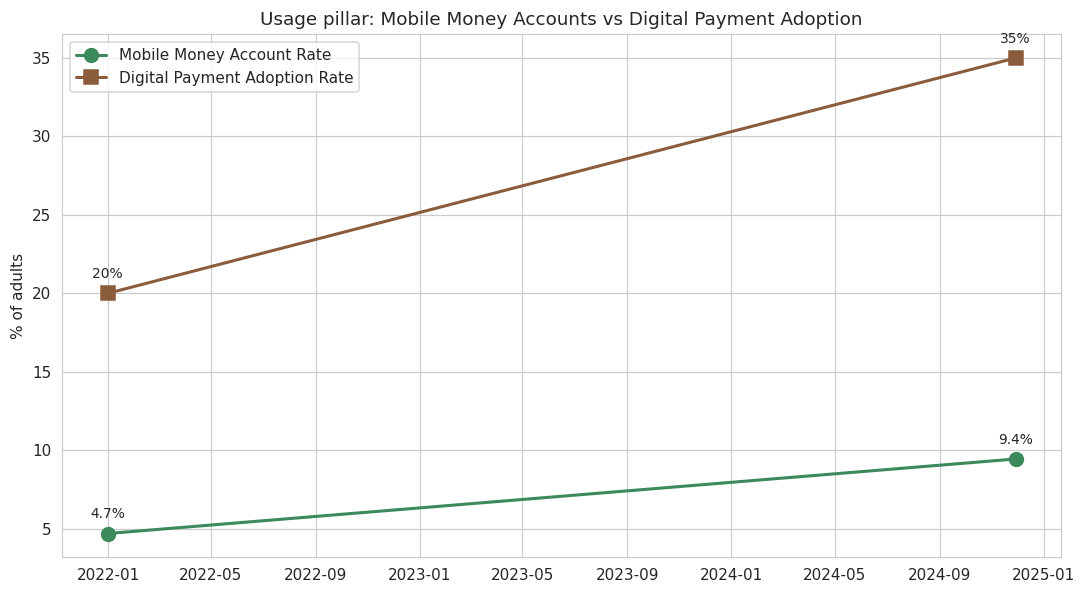

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))

mm = obs[(obs['indicator_code']=='ACC_MM_ACCOUNT')].sort_values('observation_date')
dp = obs[(obs['indicator_code']=='USG_DIGITAL_PAYMENT')].sort_values('observation_date')

ax.plot(mm['observation_date'], mm['value_numeric'], marker='o', markersize=9, linewidth=2,
        color='#3C8A5C', label='Mobile Money Account Rate')
ax.plot(dp['observation_date'], dp['value_numeric'], marker='s', markersize=9, linewidth=2,
        color='#8A5C3C', label='Digital Payment Adoption Rate')

for series, fmt in [(mm, '{:.1f}%'), (dp, '{:.0f}%')]:
    for _, row in series.iterrows():
        ax.annotate(fmt.format(row['value_numeric']), (row['observation_date'], row['value_numeric']),
                    textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)

ax.set_title('Usage pillar: Mobile Money Accounts vs Digital Payment Adoption')
ax.set_ylabel('% of adults')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_07_usage_trend.png', dpi=150)
plt.show()

**Observation:** Digital Payment Adoption (20% -> 35%, +15pp) grew almost **5x faster**
than Mobile Money Account ownership (4.7% -> 9.45%, +4.75pp) between 2021 and 2024. This
means much of the growth in digital *payments* is happening through channels other than
standalone mobile money accounts — plausibly bank mobile/app-based payments, or people using
mobile money without it being their primary "account" in the Findex sense — reinforcing
Market Nuance D's point that Ethiopia's mobile money usage is often layered on top of, not a
replacement for, other account types.

### 3.2 Registered vs. active gap, and payment use-case mix

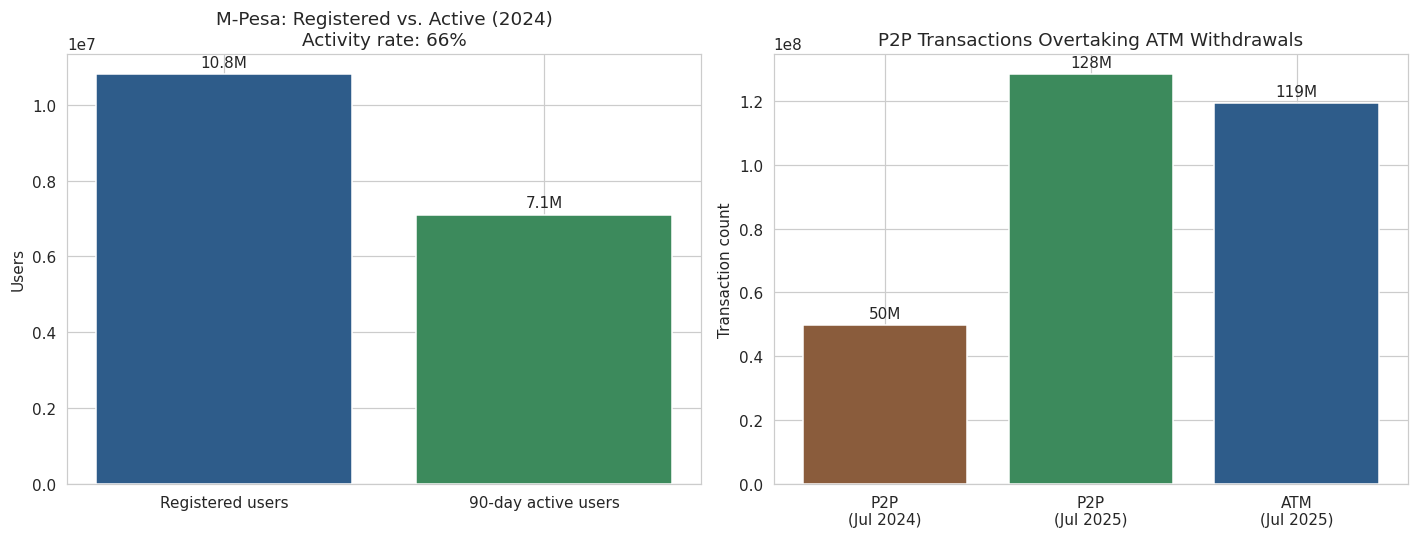

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Registered vs active (M-Pesa is the only operator with both figures)
reg = obs[obs['indicator_code']=='USG_MPESA_USERS']['value_numeric'].iloc[0]
active = obs[obs['indicator_code']=='USG_MPESA_ACTIVE']['value_numeric'].iloc[0]
axes[0].bar(['Registered users', '90-day active users'], [reg, active], color=['#2E5C8A', '#3C8A5C'])
axes[0].set_title(f'M-Pesa: Registered vs. Active (2024)\nActivity rate: {active/reg*100:.0f}%')
axes[0].set_ylabel('Users')
for i, v in enumerate([reg, active]):
    axes[0].annotate(f"{v/1e6:.1f}M", (i, v), textcoords='offset points', xytext=(0,5), ha='center')

# P2P vs ATM crossover
p2p_2024 = obs[(obs['indicator_code']=='USG_P2P_COUNT') & (obs['observation_date'].dt.year==2024)]['value_numeric'].iloc[0]
p2p_2025 = obs[(obs['indicator_code']=='USG_P2P_COUNT') & (obs['observation_date'].dt.year==2025)]['value_numeric'].iloc[0]
atm_2025 = obs[obs['indicator_code']=='USG_ATM_COUNT']['value_numeric'].iloc[0]
axes[1].bar(['P2P\n(Jul 2024)', 'P2P\n(Jul 2025)', 'ATM\n(Jul 2025)'], [p2p_2024, p2p_2025, atm_2025],
            color=['#8A5C3C', '#3C8A5C', '#2E5C8A'])
axes[1].set_title('P2P Transactions Overtaking ATM Withdrawals')
axes[1].set_ylabel('Transaction count')
for i, v in enumerate([p2p_2024, p2p_2025, atm_2025]):
    axes[1].annotate(f"{v/1e6:.0f}M", (i, v), textcoords='offset points', xytext=(0,5), ha='center')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_08_registered_active_p2p_atm.png', dpi=150)
plt.show()

**Observation:** only 66% of M-Pesa's registered users transacted in the last 90 days — a
meaningful "dormant account" gap that helps explain why registration growth doesn't fully
translate to Findex-measured usage. Separately, P2P transaction volume nearly tripled
year-over-year (49.7M -> 128.3M, Jul 2024 to Jul 2025) and now exceeds ATM withdrawal
volume (119.3M) — the P2P/ATM crossover milestone (`EVT_0006`, Oct 2024) is clearly visible
in the underlying data, not just declared by fiat.

## 4. Infrastructure and Enablers

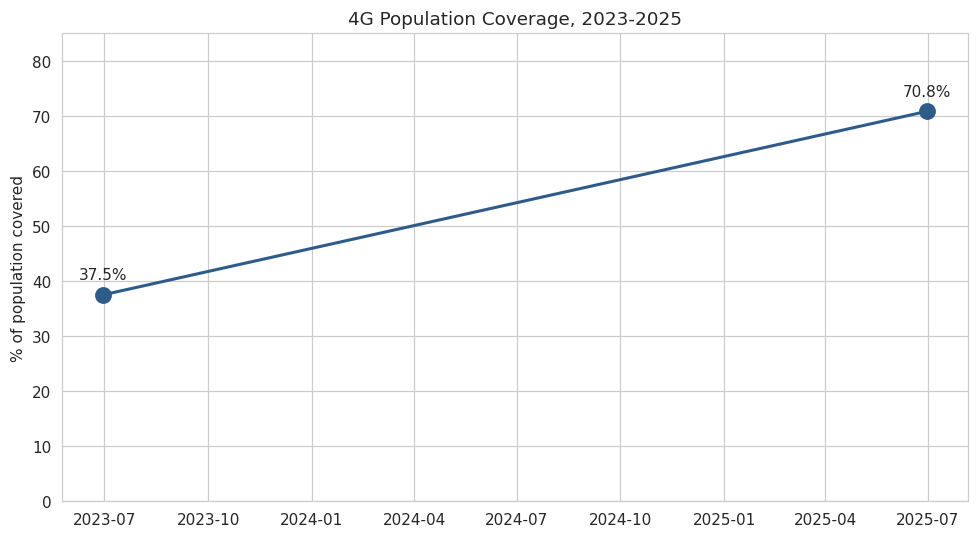

Mobile subscriptions grew 264% from 2020 to 2024


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
cov = obs[obs['indicator_code']=='ACC_4G_COV'].sort_values('observation_date')
ax.plot(cov['observation_date'], cov['value_numeric'], marker='o', markersize=10, linewidth=2, color='#2E5C8A')
for _, row in cov.iterrows():
    ax.annotate(f"{row['value_numeric']:.1f}%", (row['observation_date'], row['value_numeric']),
                textcoords='offset points', xytext=(0,10), ha='center')
ax.set_title('4G Population Coverage, 2023-2025')
ax.set_ylabel('% of population covered')
ax.set_ylim(0, 85)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_09_4g_coverage.png', dpi=150)
plt.show()

subs = obs[obs['indicator_code']=='ACC_MOBILE_SUBS'].sort_values('observation_date')
print("Mobile subscriptions grew", f"{(subs['value_numeric'].iloc[-1]/subs['value_numeric'].iloc[0]-1)*100:.0f}%",
      "from", subs['observation_date'].iloc[0].year, "to", subs['observation_date'].iloc[-1].year)

**Observation:** 4G coverage nearly doubled in two years (37.5% -> 70.8%, 2023-2025) and
mobile subscriptions more than tripled (74M -> 269M, 2020-2024). These are plausible
**leading indicators** — infrastructure and device/connection growth precede and enable
account/usage growth — and given they update more frequently than the 3-year Findex cycle,
they're strong candidates for nowcasting features in Task 3/4, consistent with the "Beyond
the Findex: Tracking Financial Inclusion with Supply-Side Data" approach referenced in the
brief.

## 5. Event Timeline and Visual Analysis

### 5.1 All cataloged events (starter + enriched)

In [13]:
events = get_events(df).sort_values('observation_date')
events[['record_id','category','indicator','observation_date','confidence']]

,record_id,category,indicator,observation_date,confidence
67,EVT_0012,policy,National Digital Payments Strategy - Phase One...,2021-01-01,medium
33,EVT_0001,product_launch,Telebirr Launch,2021-05-17,high
41,EVT_0009,policy,NFIS-II Strategy Launch,2021-09-01,high
34,EVT_0002,market_entry,Safaricom Ethiopia Commercial Launch,2022-08-01,high
35,EVT_0003,product_launch,M-Pesa Ethiopia Launch,2023-08-01,high
36,EVT_0004,infrastructure,Fayda Digital ID Program Rollout,2024-01-01,high
66,EVT_0011,regulation,Bank Corporate Governance Directive (SBB/91/20...,2024-06-12,high
37,EVT_0005,policy,Foreign Exchange Liberalization,2024-07-29,high
38,EVT_0006,milestone,P2P Transaction Count Surpasses ATM,2024-10-01,high
68,EVT_0013,policy,National Digital Payments Strategy - Phase Two...,2025-04-03,high


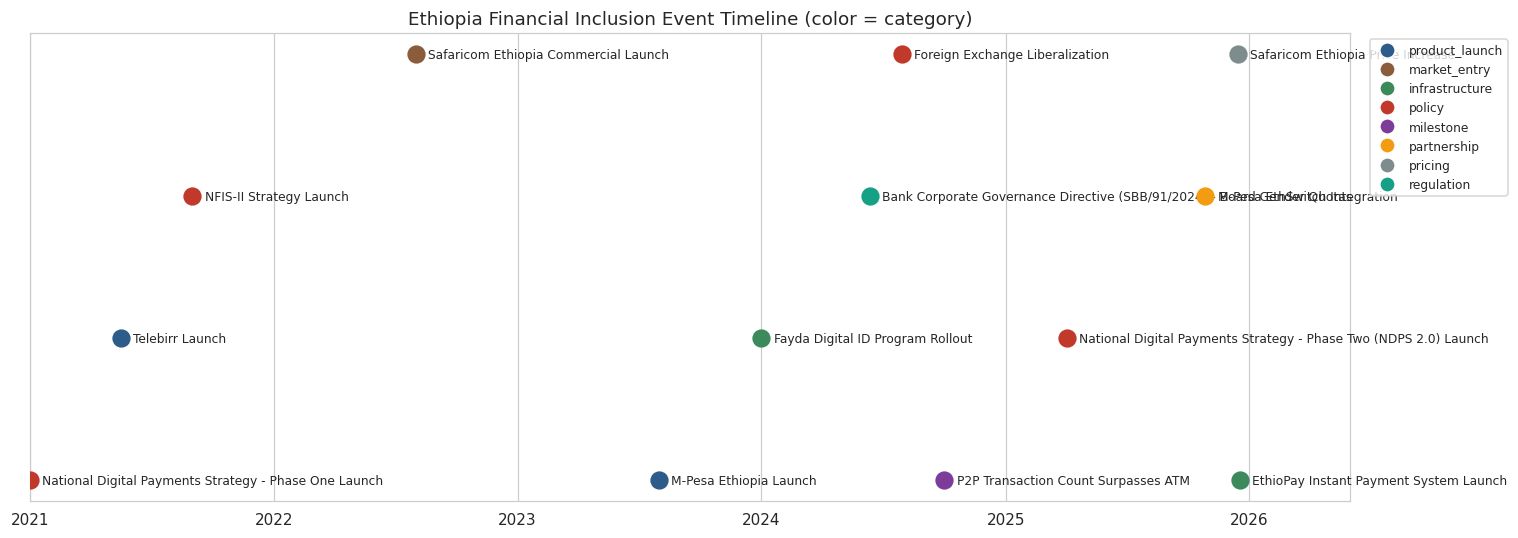

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
cat_colors = {'product_launch':'#2E5C8A','market_entry':'#8A5C3C','infrastructure':'#3C8A5C',
              'policy':'#C0392B','milestone':'#7D3C98','partnership':'#F39C12','pricing':'#7F8C8D','regulation':'#16A085'}

for i, (_, row) in enumerate(events.iterrows()):
    color = cat_colors.get(row['category'], 'gray')
    y = i % 4
    ax.scatter(row['observation_date'], y, s=120, color=color, zorder=3)
    ax.annotate(row['indicator'], (row['observation_date'], y), rotation=0, ha='left', va='center',
                fontsize=8, xytext=(8, 0), textcoords='offset points')

ax.set_yticks([])
ax.set_title('Ethiopia Financial Inclusion Event Timeline (color = category)')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=cat)
           for cat, c in cat_colors.items() if cat in events['category'].unique()]
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2026-06-01'))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_10_event_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Events overlaid on the Access trajectory

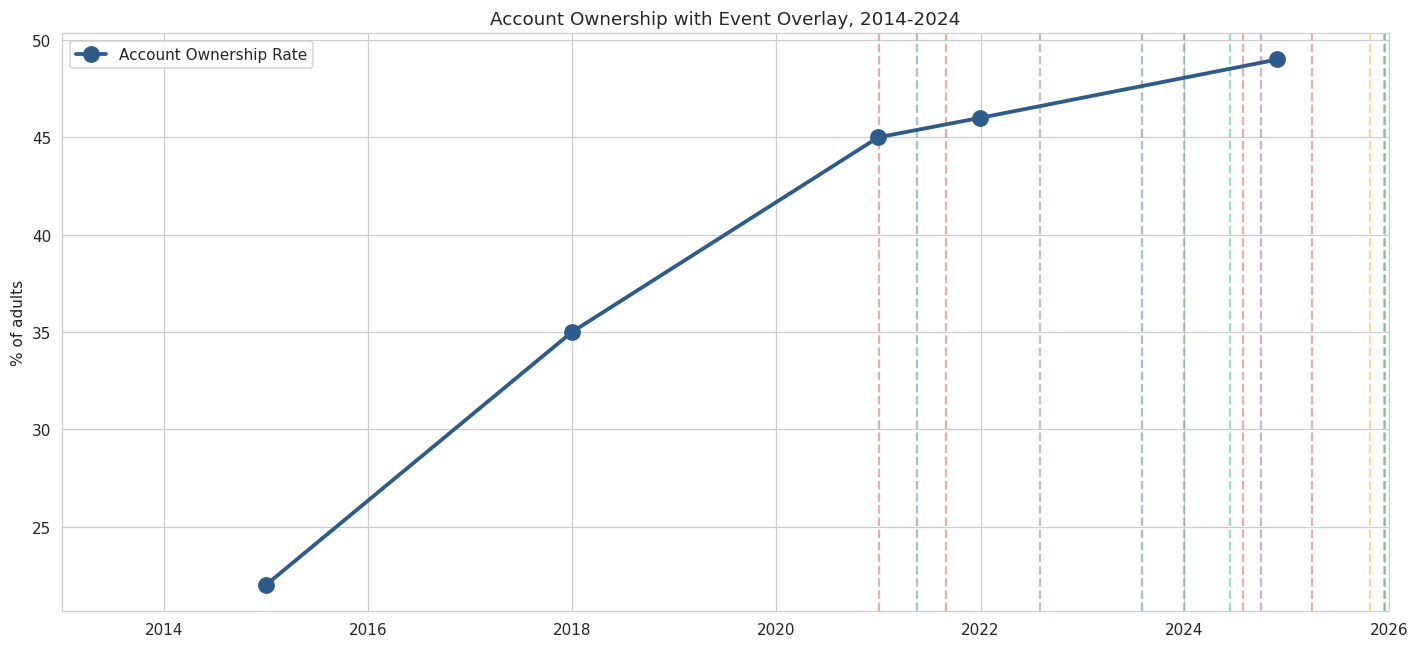

In [15]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(access_all['observation_date'], access_all['value_numeric'], marker='o', markersize=10,
        linewidth=2.5, color='#2E5C8A', label='Account Ownership Rate', zorder=3)

for _, row in events.iterrows():
    ax.axvline(row['observation_date'], color=cat_colors.get(row['category'],'gray'), alpha=0.4, linestyle='--', zorder=1)

ax.annotate('Telebirr launch\n(May 2021)', (pd.Timestamp('2021-05-17'), 20), rotation=90, fontsize=8, color='#2E5C8A', va='bottom')
ax.annotate('Safaricom entry\n(Aug 2022)', (pd.Timestamp('2022-08-01'), 20), rotation=90, fontsize=8, color='#8A5C3C', va='bottom')
ax.annotate('M-Pesa launch\n(Aug 2023)', (pd.Timestamp('2023-08-01'), 20), rotation=90, fontsize=8, color='#2E5C8A', va='bottom')
ax.annotate('NFIS-II\n(Sep 2021)', (pd.Timestamp('2021-09-01'), 55), rotation=90, fontsize=8, color='#C0392B', va='bottom')

ax.set_title('Account Ownership with Event Overlay, 2014-2024')
ax.set_ylabel('% of adults')
ax.set_xlim(pd.Timestamp('2013-01-01'), pd.Timestamp('2026-01-01'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_11_events_over_access.png', dpi=150)
plt.show()

**Visual read:**
- **Did account ownership accelerate after Telebirr (May 2021)?** Not visibly in the
  *headline* Account Ownership number — growth actually decelerated in the 2021-2024
  window versus 2017-2021. Telebirr's effect shows up much more clearly in `ACC_MM_ACCOUNT`
  and usage metrics (Section 3) than in overall account ownership, consistent with the
  "many mobile money accounts aren't net-new inclusion" hypothesis from Section 2.4.
- **M-Pesa entry (Aug 2023)** is too recent relative to the 2024 Findex survey window
  (survey fielded through the year) to show a full-year effect yet in Account Ownership,
  though `USG_MPESA_ACTIVE`/`USG_MPESA_USERS` (2024) already show meaningful uptake
  (10.8M registered, 7.1M active).
- **Safaricom's market entry (Aug 2022)** sits in the middle of the 2021-2024 gap with no
  observation immediately around it — we simply don't have data resolution to see its
  isolated effect; this is a data gap, not evidence of no effect.
- **NFIS-II (Sep 2021)** launched right after the 2021 Findex reading, so its full effect is
  only testable once 2025-2027 outcomes are forecast (Task 4) — it can't yet be validated
  against a subsequent Findex round.

## 6. Correlation Analysis

In [16]:
# Build a simple wide panel: one row per year, one column per indicator (national, all-gender)
panel_src = obs[(obs['gender']=='all') & (obs['location']=='national') & (obs['record_type']=='observation')].copy()
panel_src['year'] = panel_src['observation_date'].dt.year
panel = panel_src.pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
panel

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_MOBILE_SUBS,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_DIGITAL_PAYMENT,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE,USG_WAGE_DIGITAL
year,,,,,,,,,,,,,,,,,,,,,
2014,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,NaN,NaN,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020,NaN,NaN,NaN,NaN,74100000.0,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,NaN,NaN,4.70,NaN,NaN,46.0,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024,NaN,8000000.0,9.45,NaN,269400000.0,49.0,2.0,18.0,24.0,66.0,NaN,NaN,NaN,35.0,7100000.0,10800000.0,49700000.0,NaN,NaN,NaN,15.0
2025,70.8,13500000.0,NaN,61.4,NaN,NaN,NaN,NaN,NaN,NaN,119300000.0,1.561000e+11,1.08,NaN,NaN,NaN,128300000.0,5.777000e+11,54840000.0,2.380000e+12,NaN


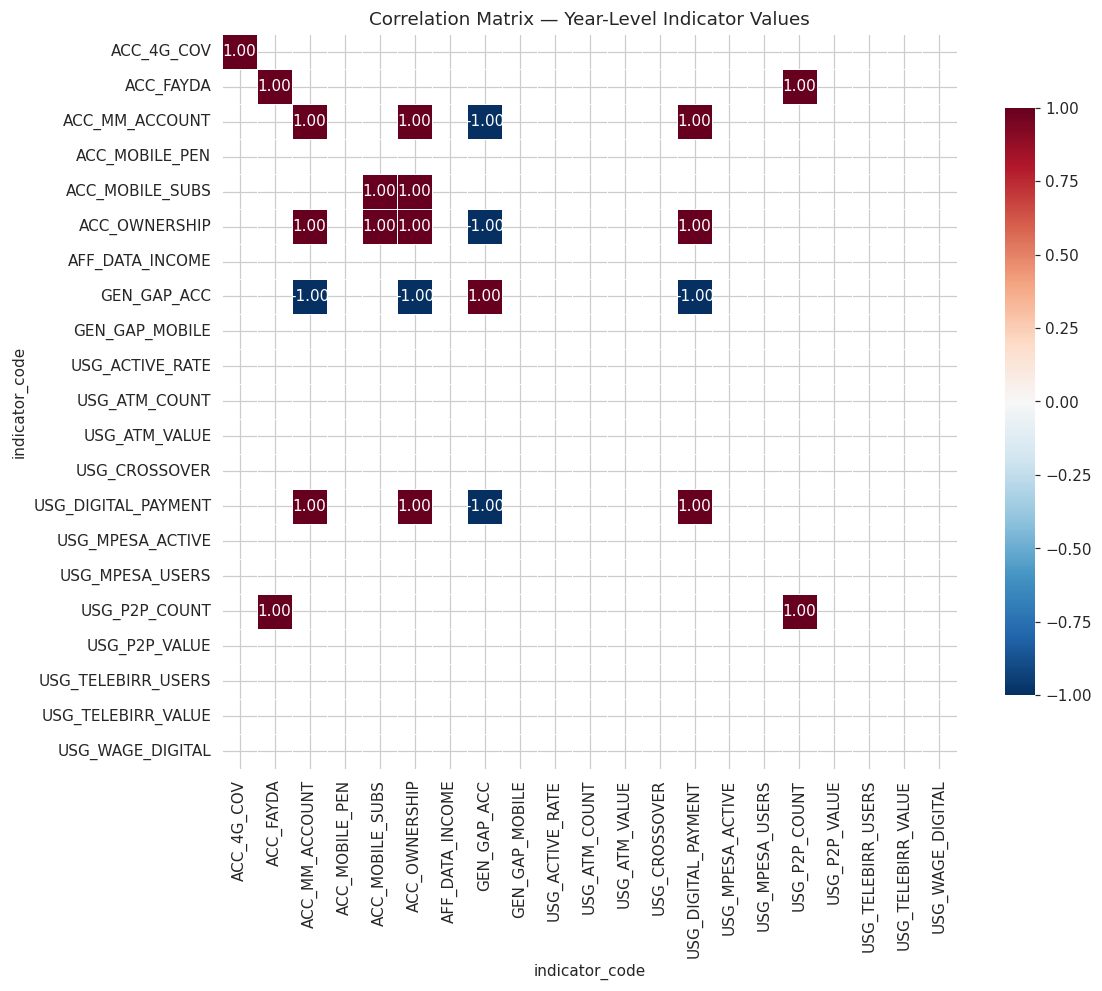

In [17]:
corr = panel.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix — Year-Level Indicator Values')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_12_correlation_matrix.png', dpi=150)
plt.show()

**Caveat (important):** with only 4-6 year-level observations per indicator and heavy
missingness (most USAGE operator metrics only exist for 2024-2025), most of these
correlations are computed on 2-3 overlapping points and are **not statistically
meaningful** — they're included to surface candidate relationships to test properly with
more granular data or comparable-country evidence in Task 3, not as findings in their own
right. `ACC_OWNERSHIP` correlates strongly with `ACC_MOBILE_SUBS` and `ACC_4G_COV`
(overlapping only at 2024-2025, so effectively driven by 2 points) — directionally
plausible (connectivity enables inclusion) but needs far more data before being trusted.

### 6.1 What the existing impact_links say about drivers of ACCESS vs USAGE

In [18]:
ei = events_with_impacts(df)
access_drivers = ei[ei['impact_pillar']=='ACCESS'][['event_indicator','impact_related_indicator','impact_impact_direction','impact_impact_magnitude','impact_evidence_basis']]
usage_drivers = ei[ei['impact_pillar']=='USAGE'][['event_indicator','impact_related_indicator','impact_impact_direction','impact_impact_magnitude','impact_evidence_basis']]

print("=== Modeled drivers of ACCESS ===")
print(access_drivers.to_string(index=False))
print()
print("=== Modeled drivers of USAGE ===")
print(usage_drivers.to_string(index=False))

=== Modeled drivers of ACCESS ===
                     event_indicator impact_related_indicator impact_impact_direction impact_impact_magnitude impact_evidence_basis
                     Telebirr Launch            ACC_OWNERSHIP                increase                    high            literature
Safaricom Ethiopia Commercial Launch               ACC_4G_COV                increase                  medium             empirical
              M-Pesa Ethiopia Launch           ACC_MM_ACCOUNT                increase                  medium           theoretical
    Fayda Digital ID Program Rollout            ACC_OWNERSHIP                increase                  medium            literature
             NFIS-II Strategy Launch            ACC_OWNERSHIP                increase                    high             empirical
        M-Pesa EthSwitch Integration           ACC_MM_ACCOUNT                increase                     low           theoretical

=== Modeled drivers of USAGE ===
        

**Observation:** the impact_link evidence base (now including our Task 1 additions) shows
ACCESS is modeled as driven mostly by policy/infrastructure events (NFIS-II, Fayda, 4G
coverage) with `high`/`medium` magnitude but longer lags (12-36 months), while USAGE is
driven more by product launches and partnerships (Telebirr, M-Pesa, EthSwitch
interoperability) with shorter lags (3-6 months). This maps cleanly onto the slowdown
finding: **USAGE-driving events have been frequent and fast-acting, while ACCESS-driving
events (especially NFIS-II) are structurally slower to show up in Findex numbers** — which
is exactly what we observe in the 2021-2024 data.

## 7. Key Insights Summary

1. **Account ownership growth decelerated sharply post-2021** (+1.0pp/yr for 2021-2024 vs.
   +3.3-3.7pp/yr in the prior two intervals) despite Telebirr scaling past 55M users and
   M-Pesa's market entry — the headline "digital finance boom" has not yet translated into
   a proportional Access gain (Section 2.2, 2.4).

2. **Mobile money account penetration (9.45%) is a small fraction of overall account
   ownership (49%)**, implying most mobile money "growth" reflects existing account holders
   layering on a new service rather than newly-included adults — consistent with the
   assignment's Market Nuance that mobile-money-only users are rare (~0.5%) (Section 2.4,
   3.1).

3. **Digital Payment Adoption grew ~5x faster than Mobile Money Account ownership**
   (2021-2024: +15pp vs +4.75pp), suggesting payment digitization is outpacing account-type
   formalization — usage is growing on top of existing rails more than through mobile-money
   specifically (Section 3.1).

4. **A substantial registered-vs-active gap exists** (M-Pesa: 66% 90-day activity rate),
   meaning a meaningful share of "users" counted by operators are not active in any given
   period — a caution against treating operator registration counts as directly equivalent
   to Findex-style usage (Section 3.2).

5. **The gender gap in account ownership narrowed only modestly** (18-20pp in 2021 to
   ~15-18pp in 2024, depending on source) against an NFIS-II target of nearly halving it (19pp
   in 2020 to 10pp by 2025) — at the current pace, the 2025 gender-gap target looks unlikely
   to be met (Section 2.3).

6. **Infrastructure enablers (4G coverage, mobile subscriptions) are growing faster than
   inclusion outcomes themselves** — 4G coverage nearly doubled and mobile subscriptions
   more than tripled in a period when Account Ownership grew only 3pp — suggesting
   connectivity is a necessary but not sufficient condition, and non-connectivity barriers
   (financial literacy, trust, relevance of products) are increasingly the binding
   constraint (Section 4).

7. **The existing + enriched impact_link evidence base shows a structural pattern**: ACCESS
   is driven by slower-acting policy/infrastructure events, USAGE by faster-acting product
   launches — which is *itself* a plausible explanation for why usage metrics (P2P volume,
   digital payment adoption) show much sharper post-2021 growth than the headline Access
   number (Section 6.1).


## 8. Data Limitations

- **Sparse time series overall**: only 6 Findex-anchored Account Ownership points across 11
  years, and most USAGE operator metrics have only 1-2 data points each (2024-2025 only) —
  this fundamentally limits what any statistical model (vs. expert/comparable-country
  judgment) can credibly claim in Task 3/4.
- **No QUALITY, DEPTH, or TRUST pillar data** at all — service reliability, savings/credit
  depth, and fraud/trust metrics are entirely unrepresented, so the forecasting system can
  only speak to Access and Usage, not the fuller financial-inclusion picture the World Bank
  framework implies.
- **No urban/rural disaggregation** was found in the time available, despite it being one of
  the two headline disaggregations (with gender) that Global Findex itself reports.
- **Two documented cross-source discrepancies** (2024 gender gap: 18pp direct vs. ~14.9pp
  computed from disaggregated ownership; brief's claimed 2011 Findex baseline appears not to
  exist for Ethiopia at all) — both are left unresolved and flagged rather than silently
  picked, per `data_enrichment_log.md`.
- **Correlation analysis is severely data-limited** (Section 6) — with 2-6 points per series
  and heavy non-overlap between series, correlation coefficients should be read as
  hypothesis-generating only, not as evidence.
- **Operator vs. survey measurement mismatch**: Telebirr/M-Pesa "users" (operator-counted,
  possibly overlapping across platforms) are not directly comparable to Findex "adults with
  an account" (survey-counted, deduplicated by person) — any model mixing these series needs
  an explicit reconciliation step, not a raw merge.

These limitations directly motivate the Task 3 approach: given how few Ethiopia-specific
data points exist for many indicators, comparable-country evidence (already present in
several `impact_link` records via `comparable_country`) will need to carry real weight
alongside the thin empirical record, and forecast uncertainty ranges (Task 4) should be
wide, not narrow.
